In [1]:
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import zuko

from itertools import islice
from lampe.data import JointLoader, JointDataset
from lampe.inference import NPE, NPELoss
from lampe.plots import corner, mark_point, nice_rc
from lampe.utils import GDStep
from tqdm import trange

In [2]:
import numpy as np
def read_model_fit(file_name):
    """
    This function read the best model fit saved after the training.

    PARAMETERS:
    -----------
    file_name : str
        The path of the file containing the best model fit.

    RETURNS:
    -------
    model_params : dict
        The parameters of the best model fit.
    """

    model_params = np.load(file_name, allow_pickle=True)[()]
    
    n_hidden = [model_params[f'n_hidden_{n}'] for n in range(model_params['n_layers'])]
    
    return n_hidden, model_params['dropout_rate'], model_params['weight_decay'], model_params['lr']
from fit_functions.FCNN_utils import make_training_dataset, train_model
dataset_path = '/global/cfs/cdirs/desi/users/arocher/HODDIES_results/test/AbacusSummit_base_c000_ph000/z0.500/training_set/LRG_SHOD_6p/Hammersley/'
testset_path='/global/cfs/cdirs/desi/users/arocher/HODDIES_results/test/AbacusSummit_base_c000_ph000/z0.500/test_set/LRG_SHOD_6p/lhs/'
path_to_model='/global/homes/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/saved_model/test_model_LRG_SHOD_6p_z0.5_small_wp+xi_ells.pth'
# path_to_model=None
# testset_path=None
num_testset=200
train_Dataset, train_loader, val_loader = make_training_dataset(dataset_path, stats=['wp', 'xi_ells'], log_transform=['wp'], seed=421, batch_size=256, path_to_test_files=testset_path, num_testset=num_testset)
# model = train_model(train_loader=train_loader, min_epochs=100, val_loader=val_loader, use_std=False, Activation_fn="SiLU", path_to_model=path_to_model)
n_hidden, dr, weight_decay, lr = read_model_fit('/global/homes/a/arocher/Code/postdoc/HOD/Cosmological_emulator_ELGs/best_train_model.npy')

model = train_model(train_loader=train_loader, min_epochs=100, val_loader=val_loader, n_hidden=n_hidden, weight_decay=weight_decay, Dropout_rate=dr, Learning_rate=lr, use_std=False, 
                    Activation_fn="SiLU", path_to_model=path_to_model)

Loading test files from /global/cfs/cdirs/desi/users/arocher/HODDIES_results/test/AbacusSummit_base_c000_ph000/z0.500/test_set/LRG_SHOD_6p/lhs/
Loading training files from /global/cfs/cdirs/desi/users/arocher/HODDIES_results/test/AbacusSummit_base_c000_ph000/z0.500/training_set/LRG_SHOD_6p/Hammersley/
Applying arcsinh transform to wp
Loaded model weights from /global/homes/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/saved_model/test_model_LRG_SHOD_6p_z0.5_small_wp+xi_ells.pth


/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/FCNN_utils.py:592: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler  = GradScaler(enabled=self.use_amp)


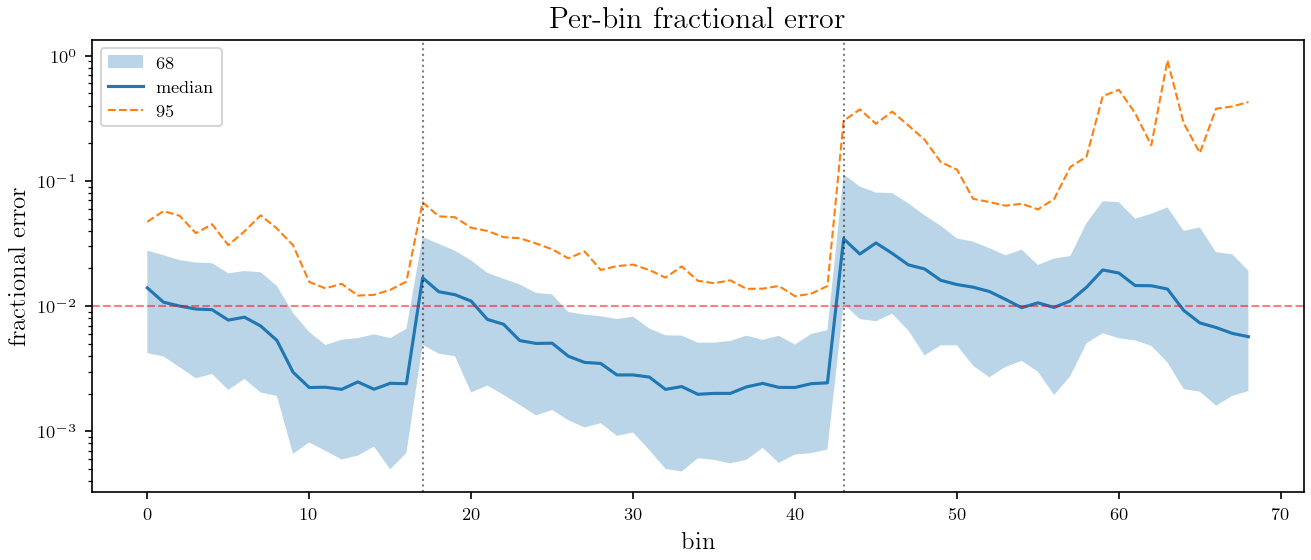

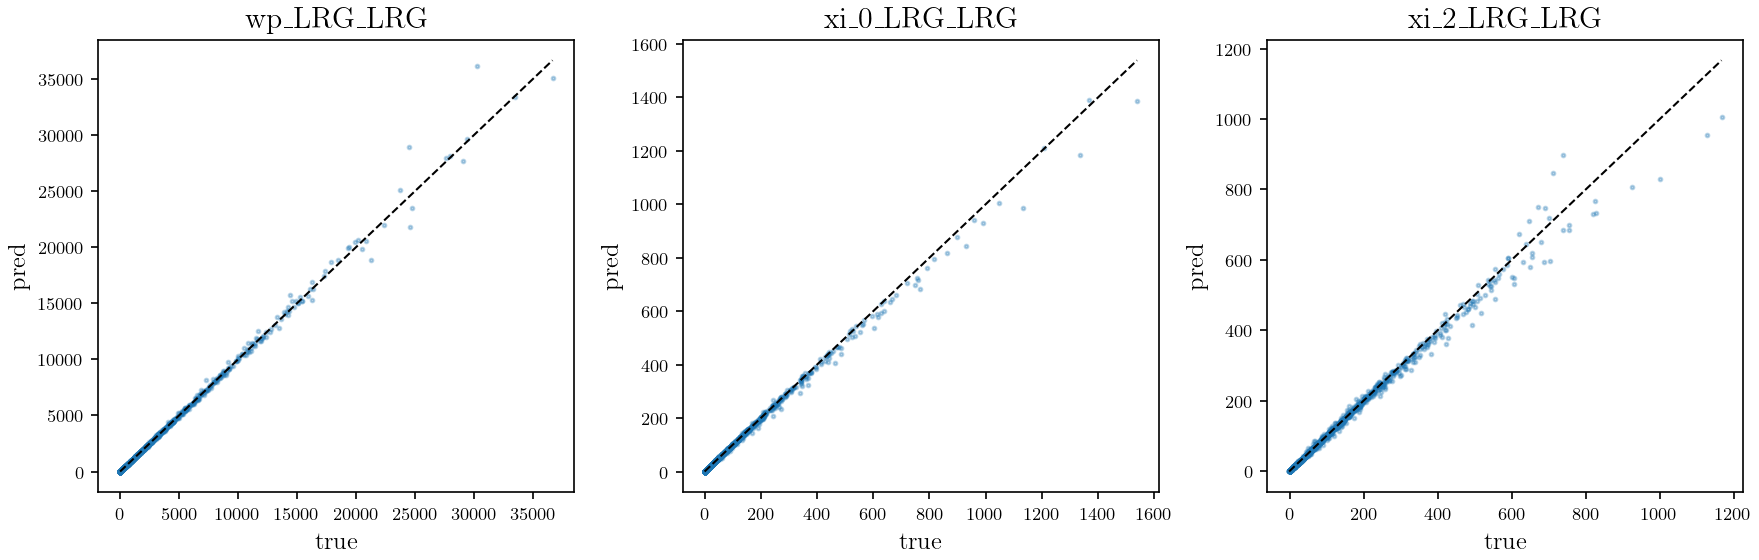

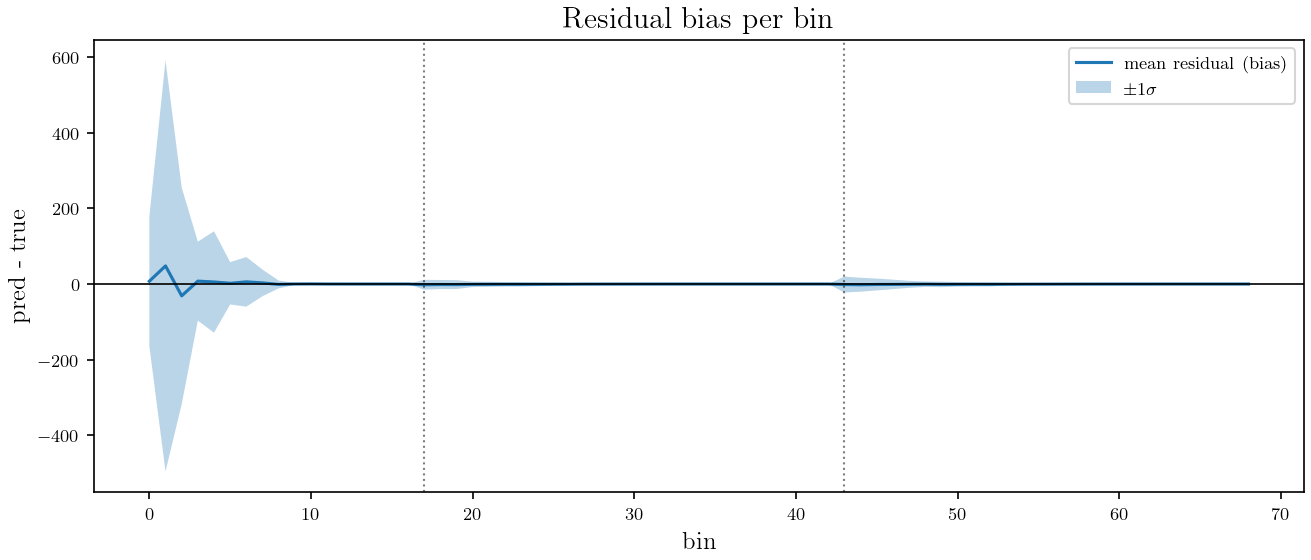

(<Figure size 1350x600 with 1 Axes>,
 <Figure size 1800x600 with 3 Axes>,
 <Figure size 1350x600 with 1 Axes>)

In [18]:
from HODDIES.fit_functions.plotting_emulator_func import plot_error_diagnostics, plot_verif
plot_error_diagnostics(train_Dataset, model)

/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/plotting_emulator_func.py:330: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


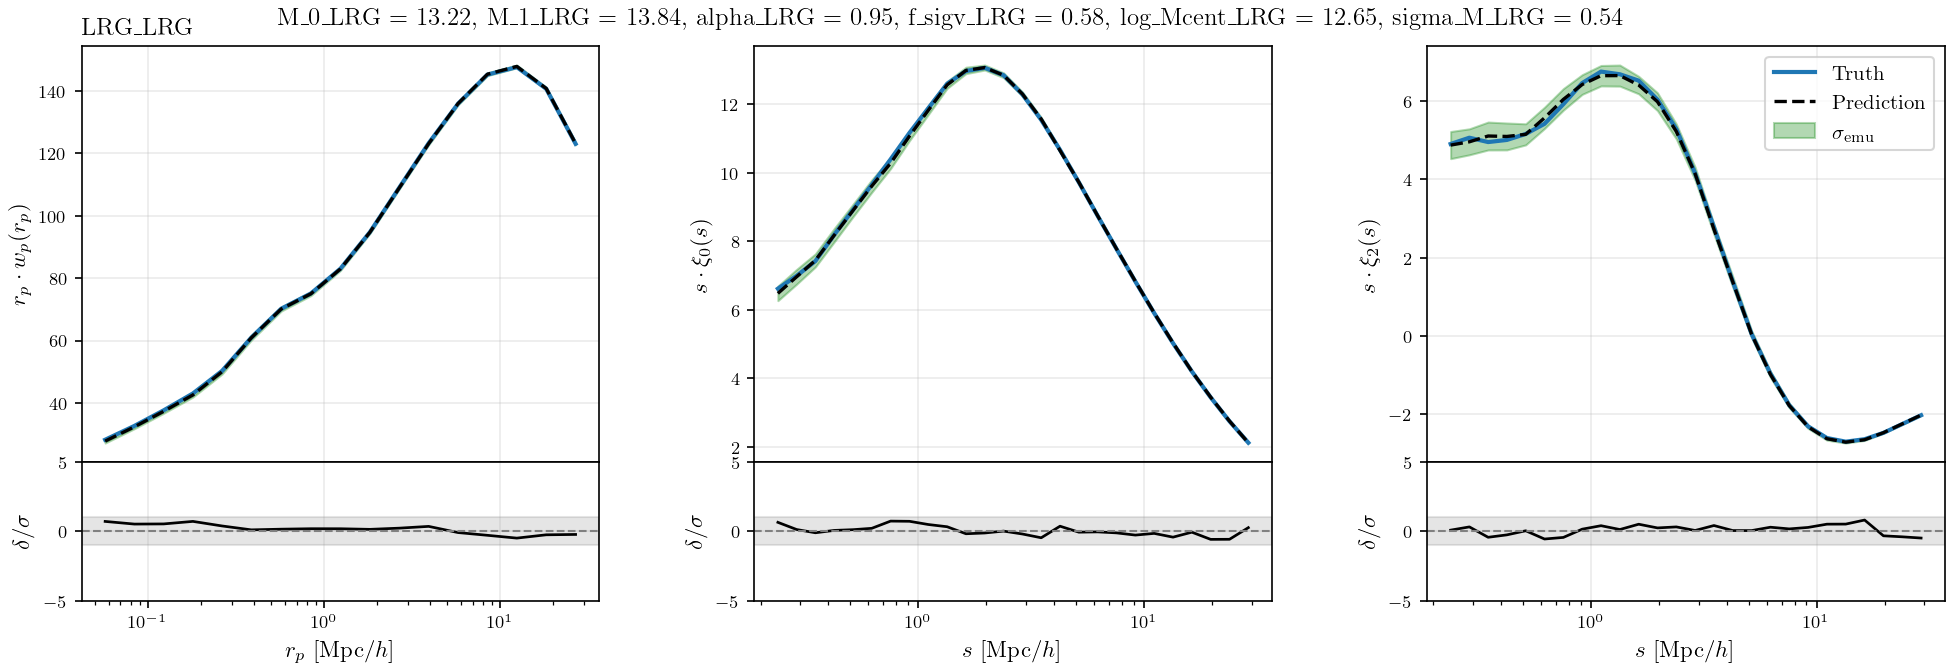

/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/plotting_emulator_func.py:330: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


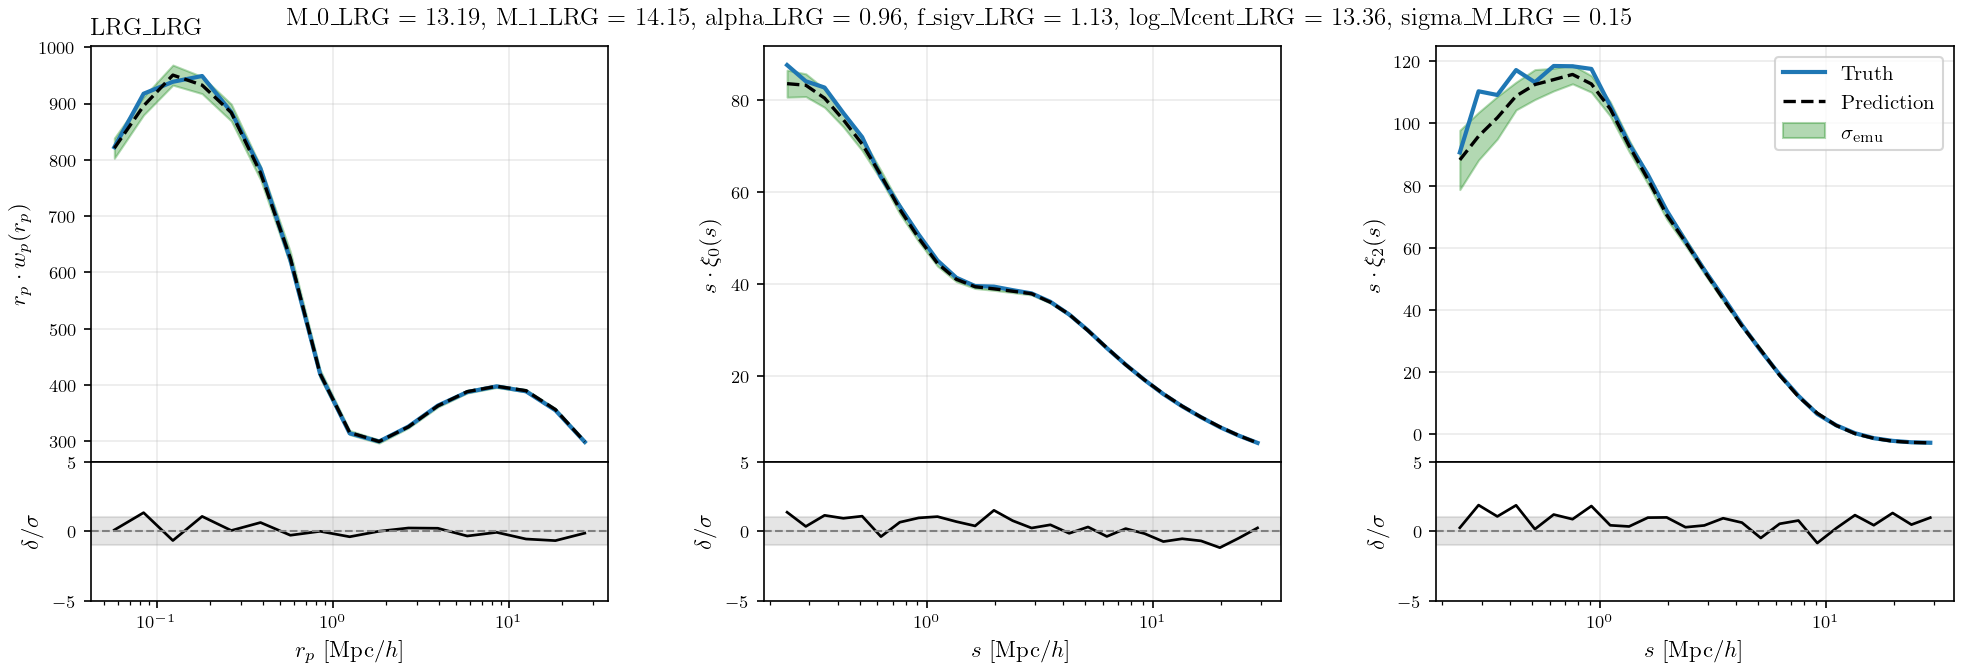

/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/plotting_emulator_func.py:330: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


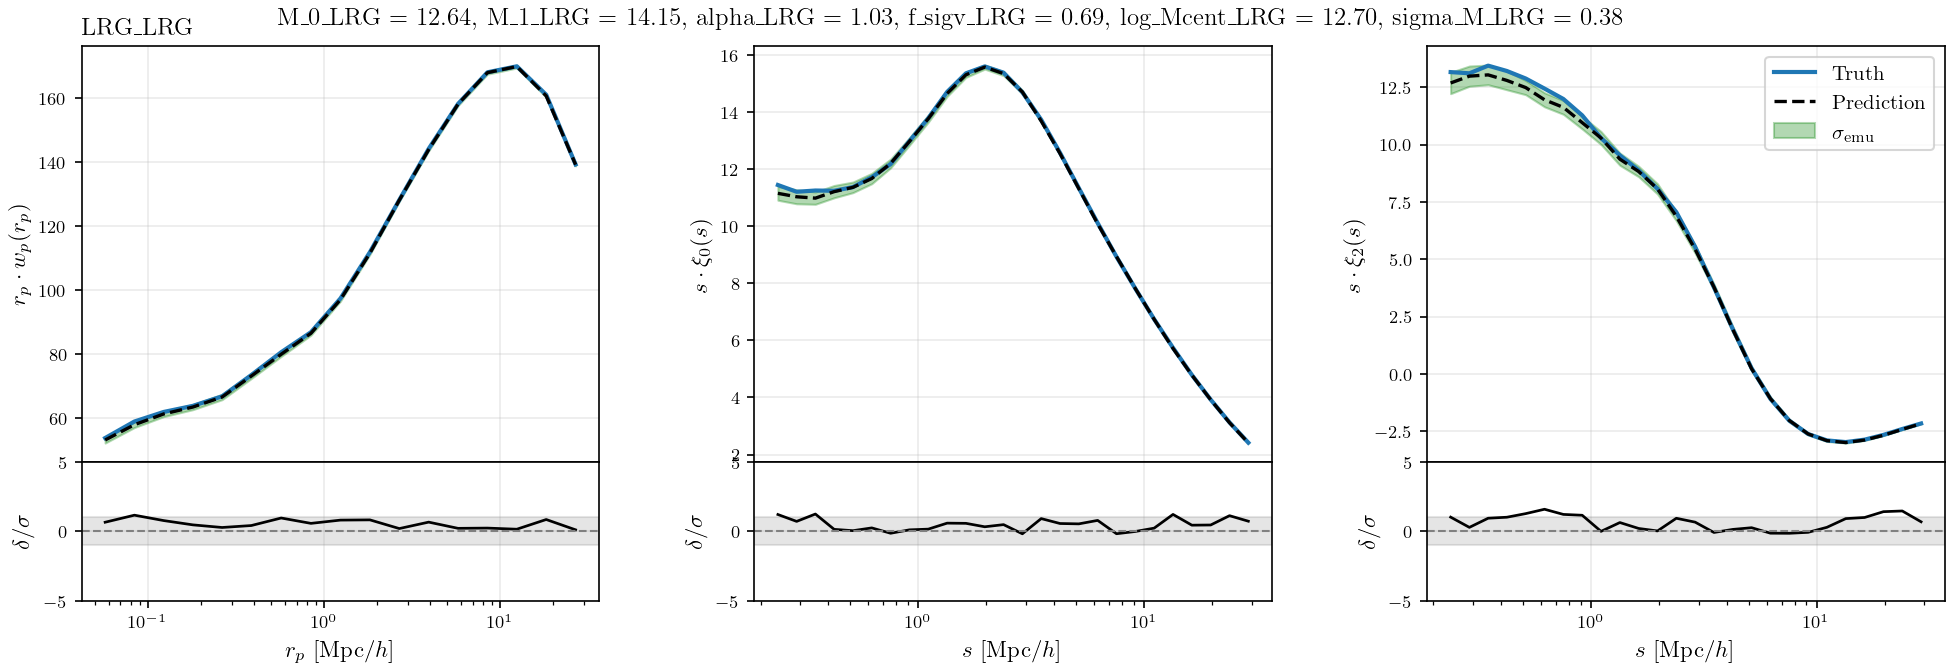

[<Figure size 2070x660 with 6 Axes>,
 <Figure size 2070x660 with 6 Axes>,
 <Figure size 2070x660 with 6 Axes>]

In [19]:
plot_verif(train_Dataset, model, nb_plots=3) # auto scale (default)


In [158]:
NPE?

Init signature:
NPE(
    theta_dim: int,
    x_dim: int,
    build: Callable[[int, int], zuko.lazy.Flow] = <class 'zuko.flows.autoregressive.MAF'>,
    **kwargs,
)
Docstring:     
Creates a neural posterior estimation (NPE) normalizing flow.

Arguments:
    theta_dim: The dimensionality :math:`D` of the parameter space.
    x_dim: The dimensionality :math:`L` of the observation space.
    build: The flow constructor (e.g. :class:`zuko.flows.spline.NSF`). It takes
        the number of sample and context features as positional arguments.
    kwargs: Keyword arguments passed to the constructor.
Init docstring: Initialize internal Module state, shared by both nn.Module and ScriptModule.
File:           ~/.local/lib/python3.12/site-packages/lampe/inference/npe.py
Type:           type
Subclasses:     

torch.nn.modules.activation.SiLU

In [176]:
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import zuko

from itertools import islice
from lampe.data import JointLoader, JointDataset
from lampe.inference import NPE, NPELoss
from lampe.plots import corner, mark_point, nice_rc
from lampe.utils import GDStep
from tqdm import trange
import numpy as np
import os
import torch
from torch import nn
import glob
from pycorr.utils import cov_to_corrcoef
from torch.utils.data import Dataset, random_split, DataLoader, TensorDataset
from typing import OrderedDict
from torch.optim.lr_scheduler import ReduceLROnPlateau


X, y = train_Dataset.extract_data()
batch_size = 256
dataset_loader = JointDataset(X, y,batch_size=batch_size, shuffle=True)
X_val, y_val = val_loader.dataset[:]
dataset_loader_val = JointDataset(X_val, y_val, batch_size=batch_size, shuffle=True)

# n_hidden, dr, weight_decay, lr

estimator = NPE(X.shape[-1], y.shape[-1], transforms=7, hidden_features=n_hidden, activation=nn.SiLU).to(model.device)

loss = NPELoss(estimator)   


optimizer = optim.AdamW(estimator.parameters(), lr=1e-3, weight_decay=weight_decay)
step = GDStep(optimizer, clip=0.5)  # gradient descent step with gradient clipping

# estimator.train()

# for epoch in (bar := trange(256, unit='epoch')):
#     losses = []

#     for theta, x in islice(dataset_loader, batch_size):  # 256 batches per epoch
#         losses.append(step(loss(theta, x))) 

#     bar.set_postfix(loss=torch.stack(losses).mean().item())
nepoch = 256
tot_loss_val, tot_loss_train = [], []
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)


use_discriminator=False
for epoch in (bar := trange(nepoch, unit='epoch')):
    losses_train, losses_val = [], []
    estimator.train()
    for theta, x in islice(dataset_loader, batch_size):  # 256 batches per epoch
        if use_discriminator:
            theta = theta.to(model.device)
            x = x.to(model.device)
            y_emu, var_emu = model.predict(estimator.flow(x).rsample((1,))[0])
            loss_yemu = nn.GaussianNLLLoss(full=True)(y_emu, x, var_emu)
        else:
            loss_yemu =0
        losses_train.append(step(loss(theta, x)+loss_yemu)) 
    estimator.eval()
    with torch.no_grad():
        for theta, x in islice(dataset_loader_val, batch_size):  # 256 batches per epoch
            if use_discriminator:
                theta = theta.to(model.device)
                x = x.to(model.device)
                y_emu, var_emu = model.predict(estimator.flow(x).rsample((1,))[0])
                loss_yemu = nn.GaussianNLLLoss(full=True)(y_emu, x, var_emu)
            else:
                loss_yemu =0
            losses_val.append(loss(theta, x)+loss_yemu)
    
    tot_loss_train += [torch.stack(losses_train).mean().cpu().numpy()]
    tot_loss_val += [torch.stack(losses_val).mean().cpu().numpy()]

    scheduler.step(tot_loss_val[-1])
    bar.set_postfix(train_loss=tot_loss_train[-1], val_loss=tot_loss_val[-1])

100%|██████████| 256/256 [01:43<00:00,  2.47epoch/s, train_loss=-5.468889, val_loss=-5.723579]    


In [138]:
from torch.cuda.amp import autocast, GradScaler


class CNN(nn.Module):
    """
    Convolutional Neural Network
    """
    def __init__(self,
                 n_input : int,
                 n_output : int,
                 n_hidden: list[int] =[512, 512, 512, 512],
                 activation_fn = 'GELU',
                 loss: str = 'rmse',
                 learning_rate: float = 1.e-3,
                 dropout_rate: float = 0.0,
                 weight_decay=2.5e-6,
                 device: str = None,
                 var_loss_weight: float = 1.0,
                 file_best_fit_train: str = None,
                 verbose: bool = True,
                 use_std: bool = False
                ):
        """
        Initialize the CNN model.

        PARAMETERS:
        -----------
        n_input : int
            Number of input features (HOD parameters).
        n_output : int
            Number of output values (e.g. number of wp bins).
        n_hidden : List[int]
            List of hidden layer sizes.
        activation_fn : str
            Activation function name (e.g., 'ReLU', 'SiLU').
        loss : str
            Type of loss function ('mse', 'rmse', 'mae').
        learning_rate : float
            Learning rate for the optimizer.
        dropout_rate : float
            Dropout rate between layers (0.0 disables it).
        device : str
            'cpu' or 'cuda' (for GPU support).
        var_loss_weight : float
            Weight for the variance loss term.
        file_best_fit_train : str, optional
            Path to a pre-trained model file to load.
        verbose : bool
            If True, print detailed information during training.
        use_std : bool
            If True, use standard deviation in the loss function.
        """
        super().__init__()
        self.n_input = n_input
        self.n_output = n_output
        if file_best_fit_train is not None:
            self.read_model_fit(file_best_fit_train)
        else:
            self.n_hidden = n_hidden
            self.learning_rate = learning_rate
            self.dropout_rate = dropout_rate
            self.weight_decay = weight_decay
    
        self.activation_fn = activation_fn
        self.loss_type = loss
        self.device = torch.device(DEVICE) if device is None else torch.device(device)
        self.var_loss_weight = var_loss_weight
        self.use_std = use_std
        

        self.model = self._build_mlp()
        self.to(self.device) 
        
        self.optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)

        # *** AMP ***
        self.use_amp = (self.device.type == "cuda")
        self.scaler  = GradScaler(enabled=self.use_amp)

        


    def _get_activation(self, layer_index: int):
        """ Returns the activation function for the given layer index. """
        return getattr(nn, self.activation_fn)()
        

    def _build_mlp(self):
        """
        Build a multi-layer perceptron (MLP) dynamically with optional dropout.
    
        PARAMETERS:
        -----------
        n_input : int
            Number of input features.
        n_hidden : list[int]
            List of hidden layer sizes.
        n_output : int
            Number of output features (e.g. length of wp).
        dropout_rate : float
            Dropout rate to apply after each activation layer (0.0 to disable).
    
        RETURNS:
        --------
        nn.Sequential
            A complete PyTorch MLP model.
        """
        model = nn.Sequential(OrderedDict())  # Create an ordered container for the layers

        in_channels = 1  # Start with input size

        for i, out_channels in enumerate([4,8]):
            # Create unique names for layers
            layer_name = f"mlp{i}"
            act_name = f"act{i}"
            dropout_name = f"dropout{i}"
    
            # Linear layer: input → hidden_dim
            cov_layer = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding='same')
            
            # Activation function: e.g., ReLU, SiLU, or LearnedSigmoid
            activation = self._get_activation(i)
    
            # Add layers to the model
            model.add_module(layer_name, cov_layer)
            model.add_module(act_name, activation)
            if self.dropout_rate > 0.0:
                model.add_module(dropout_name, nn.Dropout(self.dropout_rate))
            maxpool_layer = nn.MaxPool1d(kernel_size=2, stride=2)
            model.add_module(layer_name+'maxpool', maxpool_layer)

            # Update input size for the next layer
            in_channels = out_channels
    
        return model


    def forward(self, x):
        """
        Forward pass of the neural network.

        """

        return self.model(x[:,None, :]).view(x.size(0), -1)  # Add channel dimension for Conv1d



    
    def predict(self, X, no_grad: bool = True):
        """
        Predict output values from input HOD parameters.
    
        PARAMETERS:
        -----------
        X : Tensor
            Input tensor of shape (batch_size, n_input)
        no_grad : bool
            Whether to disable gradient tracking (default: True)
    
        RETURNS:
        --------
        Tensor: Predicted output of shape (batch_size, n_output)
        """
        self.eval()
        X = X.to(self.device)
    
        if no_grad:
            with torch.no_grad():
                return self.forward(X)
        else:
            return self.forward(X)
    


    def train_epoch(self, dataloader):
        """
        Train the model for one epoch.
        """

        self.train()
        total_loss = 0.0
    
        for X_batch, y_batch in dataloader:
            # 1) on déplace les données une seule fois
            X_batch = X_batch.to(self.device, non_blocking=True)
            y_batch = y_batch.to(self.device, non_blocking=True)
    
            self.optimizer.zero_grad(set_to_none=True)
    
            # 2) forward + backward en FP16/BF16 si GPU
            with autocast(enabled=self.use_amp):
                loss = self.compute_loss(X_batch, y_batch)
    
            # 3) mise à jour AMP
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
    
            total_loss += loss.item()
    
        return total_loss / len(dataloader)


    def fit(self,
        train_loader,
        val_loader,
        min_epochs: int = 100,
        max_epochs: int = 5000,
        patience: int = 30,          # plateau patience (early stopping)
        verbose: bool = True,
        optimizer=None):
        """
        Train the model with early stopping based on validation loss.
        The model will train at least `min_epochs`, and at most `max_epochs`.

        Parameters
        ----------
        train_loader : DataLoader
        val_loader   : DataLoader
        min_epochs   : int
            Minimum number of epochs before early stopping is allowed.
        max_epochs   : int
            Maximum number of epochs to train.
        patience     : int
            Number of epochs with no improvement before stopping.
        scheduler    : PyTorch scheduler or None
            If using ReduceLROnPlateau, pass e.g.:
                scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=10)
        """

        if optimizer is not None:
            self.optimizer = optimizer

        # IMPORTANT: create scheduler once
        scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=10)
        # self.scheduler = scheduler

        self.train_losses = []
        self.val_losses   = []

        best_val_loss = float("inf")
        best_state = None
        epochs_no_improve = 0  # for plateau tracking

        start_time = time.time()

        for epoch in range(max_epochs):

            train_loss = self.train_epoch(train_loader)
            val_loss = self.evaluate(val_loader)

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)

            if verbose and epoch % 10 == 0:
                print(f"Epoch {epoch+1}/{max_epochs} - "
                    f"Train: {train_loss:.5f} | Val: {val_loss:.5f}")

            # ---- LR Scheduler step ----
            scheduler.step(val_loss)
    
            # ---- Track best model ----
            if val_loss < best_val_loss - 1e-7:  # small tolerance
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in self.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            # ---- EARLY STOPPING ----
            if epoch + 1 >= min_epochs and epochs_no_improve >= patience:
                if verbose:
                    print(f"\n⛔ Early stopping triggered at {epoch}: no improvement for {patience} epochs.")
                break

        # Restore best weights
        if best_state is not None:
            self.load_state_dict(best_state)

        if verbose:
            print(f"\nTraining completed in {time.time() - start_time:.1f}s "
                f"| Best Val Loss: {best_val_loss:.5f}")


    @torch.no_grad()
    def evaluate(self, dataloader):
        """
        Evaluate the model on a validation or test set.
        """
        self.eval()
        total_loss = 0.0
    
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(self.device, non_blocking=True)
            y_batch = y_batch.to(self.device, non_blocking=True)
    
            with autocast(enabled=self.use_amp):
                loss = self.compute_loss(X_batch, y_batch)
            total_loss += loss.item()
    
        return total_loss / len(dataloader)

    
    def read_model_fit(self, file_best_fit_train):
        """
        Read the best model fit saved after the training.

        PARAMETERS:
        -----------
        file_name : str
            The path of the file containing the best model fit.

        RETURNS:
        -------
        model_params : dict
            The parameters of the best model fit.
        """

        model_params = np.load(file_best_fit_train, allow_pickle=True)[()]
        
        n_hidden = [model_params[f'n_hidden_{n}'] for n in range(model_params['n_layers'])]
        self.n_hidden = n_hidden
        self.learning_rate = model_params['lr']
        self.dropout_rate = model_params['dropout_rate']
        self.weight_decay = model_params['weight_decay']


    def save_model(self, path: str = "model.pth"):
        """
        Save the model weights to a file.
    
        PARAMETERS:
        -----------
        path : str
            Path to the output file (default: 'model.pth')
        """
        torch.save(self.state_dict(), path)


    def load_model(self, path: str):
        """
        Load model weights from a file.
    
        PARAMETERS:
        ----------- 
        path : str
            Path to the file where weights were saved
        """
        self.load_state_dict(torch.load(path, map_location=self.device))
        self.to(self.device)

    def plot_loss(self):
        """
        Plot the training and validation loss curves.
        """

        if getattr(self, 'train_losses', None) is None or getattr(self, 'val_losses', None) is None:
            raise ValueError("Training and validation losses are not available from a preloaded model.")
        
        fig,ax = plt.subplots(1,1,figsize=(6, 4))
        ax.plot(self.train_losses, label="Training loss")
        ax.plot(self.val_losses, label="Validation loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")

        ax.set_title(f"Training and Validation Loss \n Loss value at last epoch train {self.train_losses[-1]:.2f}, validation {self.val_losses[-1]:.2f}")
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        fig.show()
        

In [139]:
cnn = CNN(1,1, device=model.device)


/tmp/ipykernel_563033/4016501625.py:78: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler  = GradScaler(enabled=self.use_amp)


In [140]:
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import zuko

from itertools import islice
from lampe.data import JointLoader, JointDataset
from lampe.inference import NPE, NPELoss
from lampe.plots import corner, mark_point, nice_rc
from lampe.utils import GDStep
from tqdm import trange
import numpy as np
import os
import torch
from torch import nn
import glob
from pycorr.utils import cov_to_corrcoef
from torch.utils.data import Dataset, random_split, DataLoader, TensorDataset
from typing import OrderedDict
from torch.optim.lr_scheduler import ReduceLROnPlateau


X, y = train_Dataset.extract_data()
batch_size = 256
dataset_loader = JointDataset(X, y,batch_size=batch_size, shuffle=True)
X_val, y_val = val_loader.dataset[:]
dataset_loader_val = JointDataset(X_val, y_val, batch_size=batch_size, shuffle=True)
# estimator = NPE(X.shape[-1], y.shape[-1], transforms=3, hidden_features=[128] * 3).to(model.device)



from itertools import chain
cnn = CNN(1,1, device=model.device)
y_shape = cnn(torch.tensor(train_Dataset.y_norm[:1]).cuda(model.device).float()).shape[-1]
estimator = NPE(X.shape[-1], y_shape, transforms=3, hidden_features=[128] * 3).to(model.device)
loss = NPELoss(estimator)   


optimizer = optim.Adam(chain(cnn.parameters(), estimator.parameters()), lr=1e-3)
step = GDStep(optimizer, clip=0.5)  # gradient descent step with gradient clipping

# estimator.train()

# for epoch in (bar := trange(256, unit='epoch')):
#     losses = []

#     for theta, x in islice(dataset_loader, batch_size):  # 256 batches per epoch
#         losses.append(step(loss(theta, x))) 

#     bar.set_postfix(loss=torch.stack(losses).mean().item())
nepoch = 512
tot_loss_val, tot_loss_train = [], []
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)



use_discriminator=False
for epoch in (bar := trange(nepoch, unit='epoch')):
    losses_train, losses_val = [], []
    estimator.train()
    for theta, x in islice(dataset_loader, batch_size):  # 256 batches per epoch
        x = x.to(model.device)
        x_encoded = cnn(x)
        if use_discriminator:
            theta = theta.to(model.device)
            y_emu, var_emu = model.predict(estimator.flow(x_encoded).rsample((1,))[0])
            loss_yemu = nn.GaussianNLLLoss(full=True)(y_emu, x, var_emu)
        else:
            loss_yemu =0
        losses_train.append(step(loss(theta, x_encoded)+loss_yemu)) 
    estimator.eval()
    with torch.no_grad():
        for theta, x in islice(dataset_loader_val, batch_size):  # 256 batches per epoch
            x = x.to(model.device)
            x_encoded = cnn(x)
            if use_discriminator:
                theta = theta.to(model.device)
                y_emu, var_emu = model.predict(estimator.flow(x_encoded).rsample((1,))[0])
                loss_yemu = nn.GaussianNLLLoss(full=True)(y_emu, x, var_emu)
            else:
                loss_yemu =0
            losses_val.append(loss(theta, x_encoded)+loss_yemu)
    
    tot_loss_train += [torch.stack(losses_train).mean().cpu().numpy()]
    tot_loss_val += [torch.stack(losses_val).mean().cpu().numpy()]

    scheduler.step(tot_loss_val[-1])
    bar.set_postfix(train_loss=tot_loss_train[-1], val_loss=tot_loss_val[-1])

/tmp/ipykernel_563033/4016501625.py:78: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler  = GradScaler(enabled=self.use_amp)
  0%|          | 0/512 [00:00<?, ?epoch/s]

100%|██████████| 512/512 [01:28<00:00,  5.82epoch/s, train_loss=-1.2529056, val_loss=-1.48972]      


In [141]:
x_encoded.shape

torch.Size([160, 136])

In [170]:
from lampe.diagnostics import expected_coverage_mc
from lampe.plots import coverage_plot, nice_rc

LOWER = torch.from_numpy(train_Dataset.X_training.min(axis=0)) - 0.1
UPPER = torch.from_numpy(train_Dataset.X_training.max(axis=0)) + 0.1

# prior = zuko.distributions.BoxUniform(LOWER.cuda(), UPPER.cuda())
prior = zuko.distributions.BoxUniform(LOWER, UPPER)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device= torch.device("cpu")

lb = lambda x: estimator.flow(cnn(x.reshape(1, -1)).flatten())

npe_levels, npe_coverages = expected_coverage_mc(lb, islice(zip(torch.tensor(train_Dataset.x_test_norm, dtype=torch.float32).to(train_Dataset.device), torch.tensor(train_Dataset.y_test_norm, dtype=torch.float32).to(train_Dataset.device)), 256))
npe_levels, npe_coverages = expected_coverage_mc(lb, islice(zip(X_val, y_val), 256))
plt.rcParams.update(nice_rc(latex=True))  # nicer plot settings
fig = coverage_plot(npe_levels, npe_coverages, legend='NPE')

0pair [00:00, ?pair/s]

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1024x142 and 75x755)

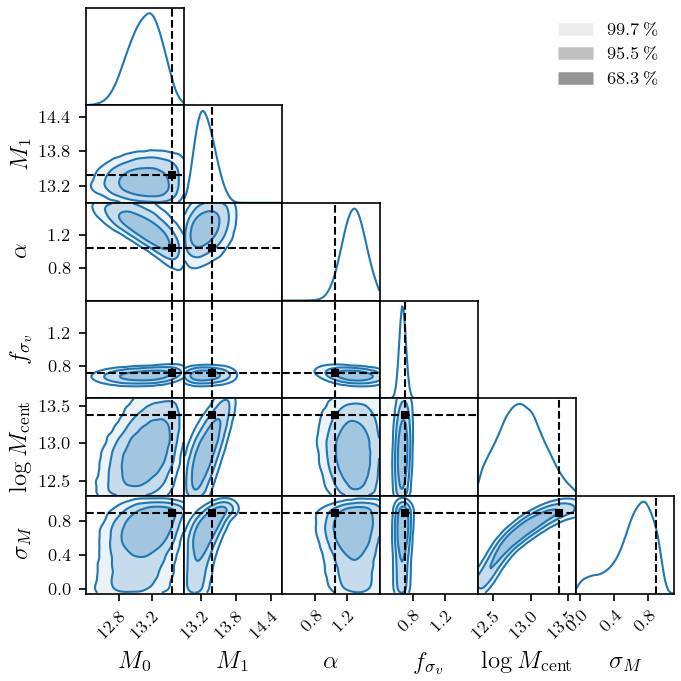

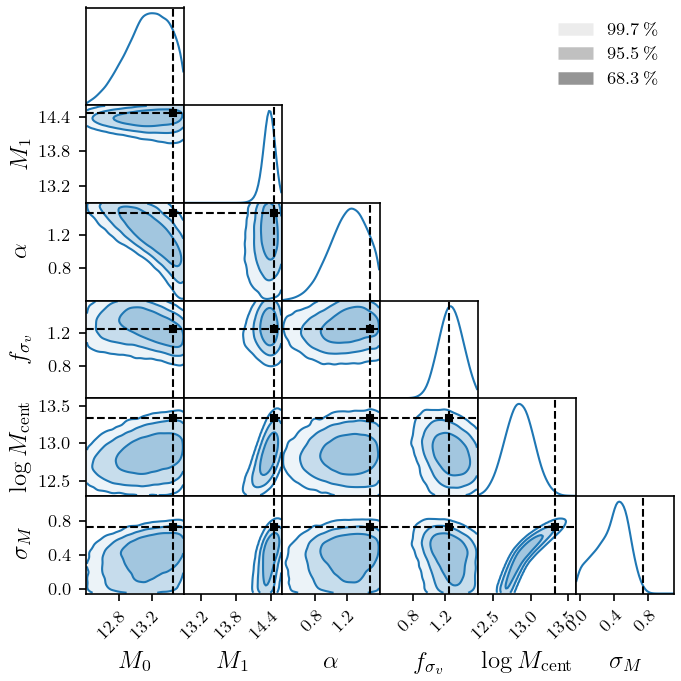

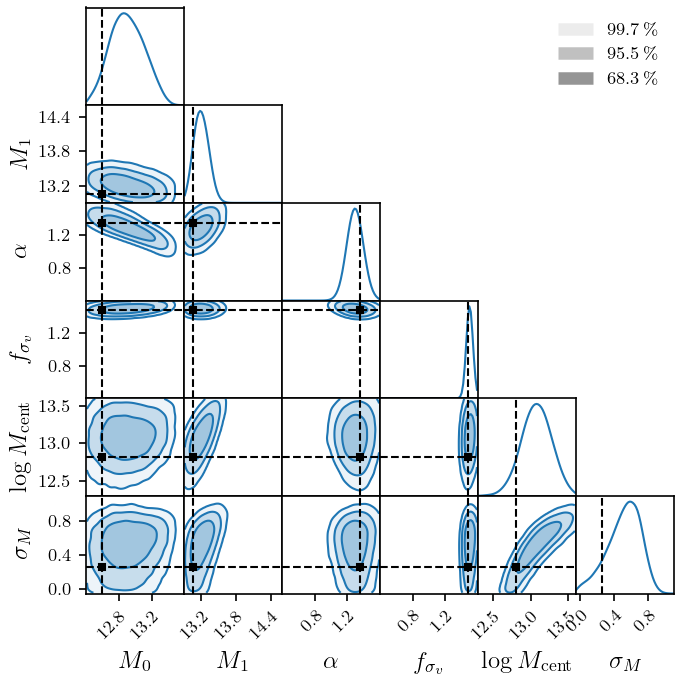

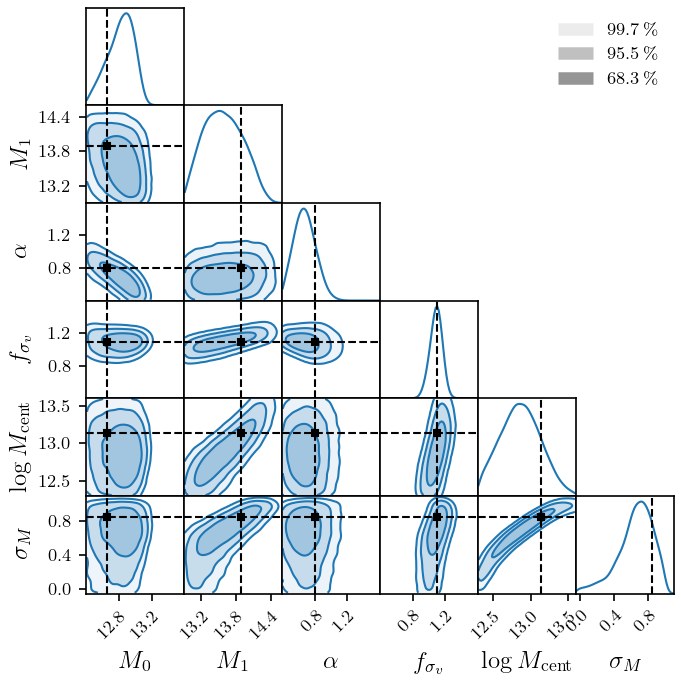

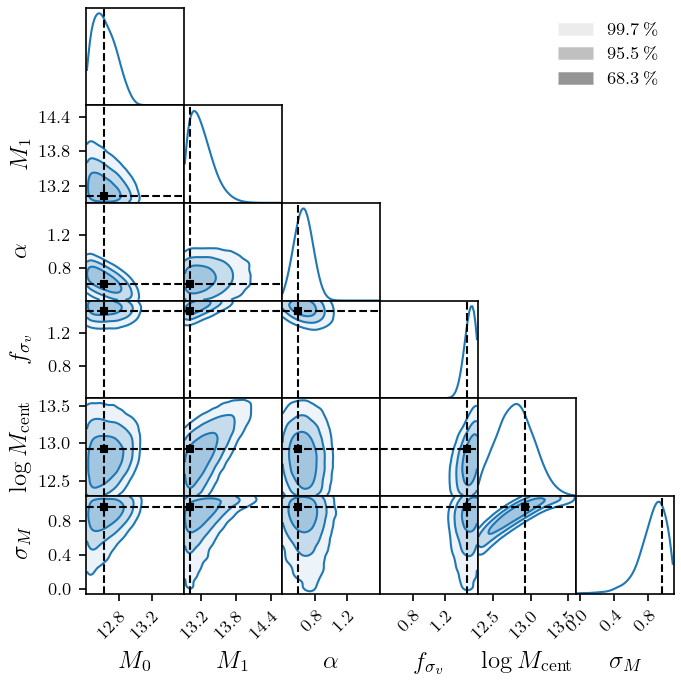

In [145]:
param_labels = {
    "Ac": r"$A_c$",
    "As": r"$A_s$",
    "M_0": r"$M_0$",
    "M_1": r"$M_1$",
    "Q": r"$Q$",
    "alpha": r"$\alpha$",
    # --- assembly bias parameters ---
    "ab_c_cen": r"$A_{B,\,c}^{\mathrm{cen}}$",
    "ab_c_sat": r"$A_{B,\,c}^{\mathrm{sat}}$",
    "ab_env_cen": r"$A_{B,\,\mathrm{env}}^{\mathrm{cen}}$",
    "ab_env_sat": r"$A_{B,\,\mathrm{env}}^{\mathrm{sat}}$",
    # --- other model parameters ---
    "f_sigv": r"$f_{\sigma_v}$",
    "gamma": r"$\gamma$",
    "log_Mcent": r"$\log M_{\mathrm{cent}}$",
    "pmax": r"$p_{\max}$",
    "sigma_M": r"$\sigma_M$",
    "exp_frac": r"$f_{\exp}$",
    "exp_scale": r"$s_{\exp}$",
    "nfw_rescale": r"$\lambda_{\mathrm{NFW}}$",
    "v_infall": r"$v_{\mathrm{infall}}$",
    "v_smear": r"$v_{\mathrm{smear}}$"
}


ii= np.random.choice(np.arange(len(train_Dataset.y_test_norm)), size=5, replace=False)
estimator.eval()
param_names = [param_labels[par[:-4]] for par in train_Dataset.name_arr]

lb = lambda x: estimator.flow(cnn(x.reshape(1, -1)).flatten())

for i in ii:
    with torch.no_grad():
        samples = lb(torch.from_numpy(train_Dataset.y_test_norm[i]).to(train_Dataset.device).float()).sample((2**16,))   
        samples_denorm = train_Dataset.normalizer.denormalize_x(samples.cpu())
    fig = corner(
        samples_denorm,
        smooth=2,
        figsize=(4.8, 4.8), 
        domain=(LOWER, UPPER),
        labels=list(param_names)
    )

    mark_point(fig, train_Dataset.X_test[i])

In [133]:
torch.from_numpy(train_Dataset.y_test_norm[i]).to(train_Dataset.device).float()

tensor([-0.5192, -0.5148, -0.5069, -0.5054, -0.5122, -0.5334, -0.5642, -0.6307,
        -0.7254, -0.8310, -0.8896, -0.8953, -0.8926, -0.8911, -0.8861, -0.8873,
        -0.8828, -0.5820, -0.5694, -0.5530, -0.5357, -0.5183, -0.5030, -0.4909,
        -0.4885, -0.4930, -0.5132, -0.5483, -0.5944, -0.6395, -0.6738, -0.6951,
        -0.7051, -0.7093, -0.7114, -0.7178, -0.7286, -0.7426, -0.7590, -0.7765,
        -0.7940, -0.8053, -0.8141, -0.6404, -0.6353, -0.6270, -0.6228, -0.6093,
        -0.5921, -0.5708, -0.5512, -0.5291, -0.5076, -0.4926, -0.4815, -0.4773,
        -0.4751, -0.4712, -0.4657, -0.4540, -0.4395, -0.4243, -0.4068, -0.3938,
        -0.3749, -0.3453, -0.2898, -0.1957, -0.0244], device='cuda:0')

In [121]:
torch.tensor(train_Dataset.y_test_norm, dtype=torch.float32).to(train_Dataset.device)[0].reshape(-1,1).flatten()

tensor([ 0.2841,  0.2398,  0.1923,  0.1178,  0.0330, -0.0718, -0.1988, -0.2927,
        -0.2452, -0.1016,  0.0182,  0.0338,  0.0350,  0.0346,  0.0336,  0.0280,
         0.0176, -0.3869, -0.3890, -0.3957, -0.3970, -0.3910, -0.3971, -0.3866,
        -0.3807, -0.3666, -0.3461, -0.3194, -0.2902, -0.2708, -0.2490, -0.2332,
        -0.2292, -0.2311, -0.2285, -0.2282, -0.2271, -0.2209, -0.2125, -0.2066,
        -0.1966, -0.1917, -0.1896, -0.3042, -0.3195, -0.3300, -0.3370, -0.3483,
        -0.3611, -0.3674, -0.3874, -0.3969, -0.3970, -0.3884, -0.3814, -0.3715,
        -0.3646, -0.3540, -0.3532, -0.3524, -0.3514, -0.3534, -0.3536, -0.3517,
        -0.3504, -0.3413, -0.3356, -0.3205, -0.2792], device='cuda:0')

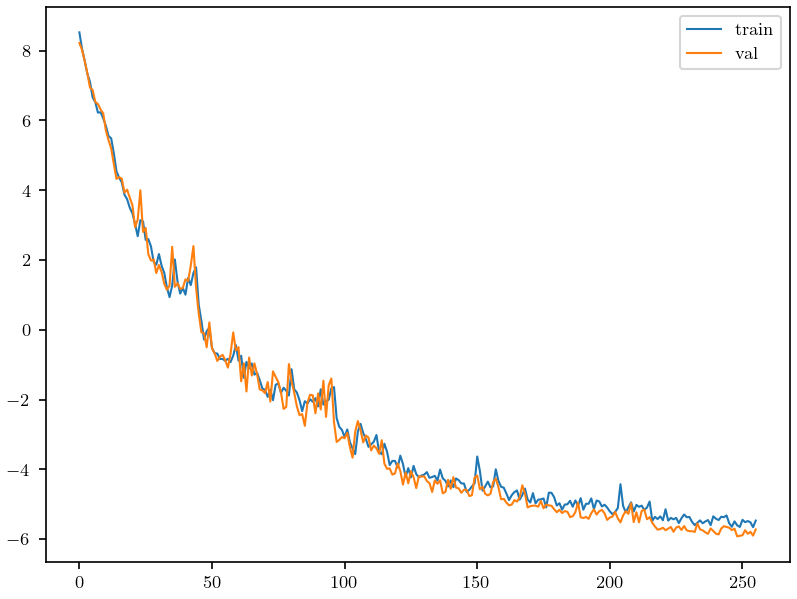

In [178]:
plt.plot(np.hstack(tot_loss_train), label='train')
plt.plot(np.hstack(tot_loss_val), label='val')
plt.legend()
# plt.yscale('log')

64pair [00:13,  4.66pair/s]


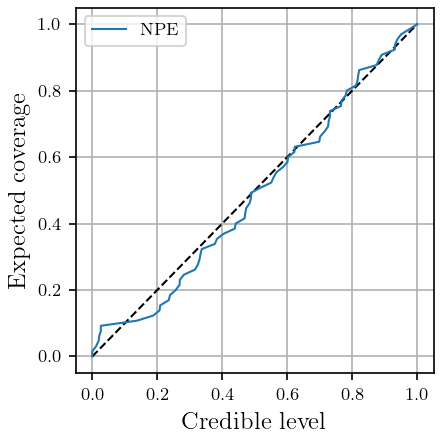

In [ ]:
from lampe.diagnostics import expected_coverage_mc
from lampe.plots import coverage_plot, nice_rc

LOWER = torch.from_numpy(train_Dataset.X_training.min(axis=0)) - 0.1
UPPER = torch.from_numpy(train_Dataset.X_training.max(axis=0)) + 0.1

# prior = zuko.distributions.BoxUniform(LOWER.cuda(), UPPER.cuda())
prior = zuko.distributions.BoxUniform(LOWER, UPPER)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device= torch.device("cpu")
npe_levels, npe_coverages = expected_coverage_mc(estimator.flow, islice(zip(torch.tensor(train_Dataset.x_test_norm, dtype=torch.float32).to(train_Dataset.device), torch.tensor(train_Dataset.y_test_norm, dtype=torch.float32).to(train_Dataset.device)), 256))
# npe_levels, npe_coverages = expected_coverage_mc(estimator.flow, islice(zip(X_val, y_val), 256))
plt.rcParams.update(nice_rc(latex=True))  # nicer plot settings
fig = coverage_plot(npe_levels, npe_coverages, legend='NPE')

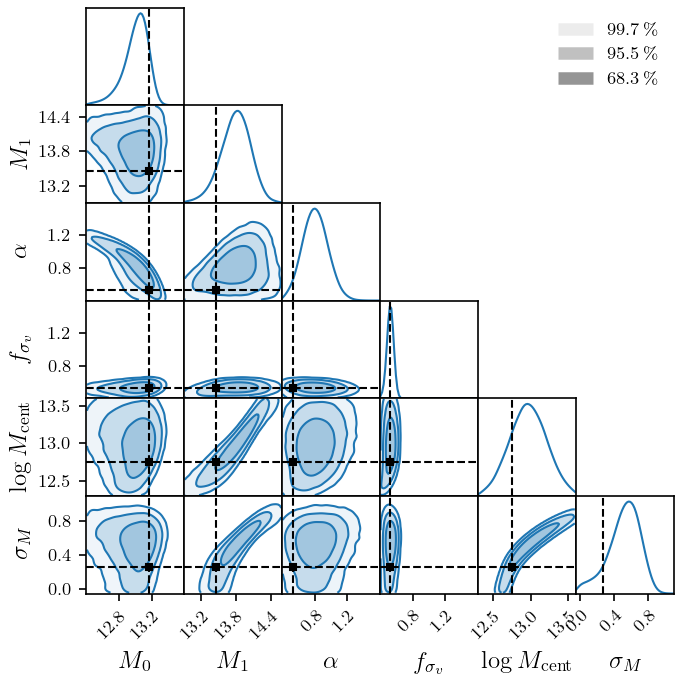

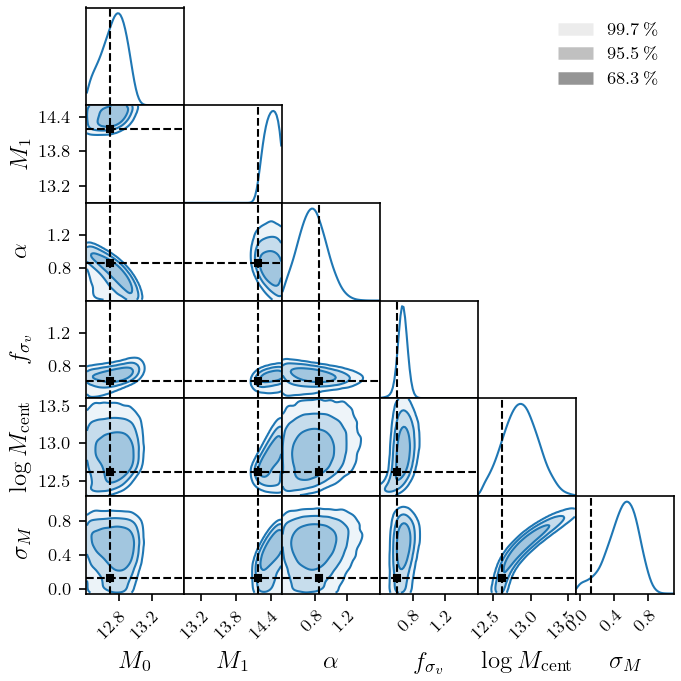

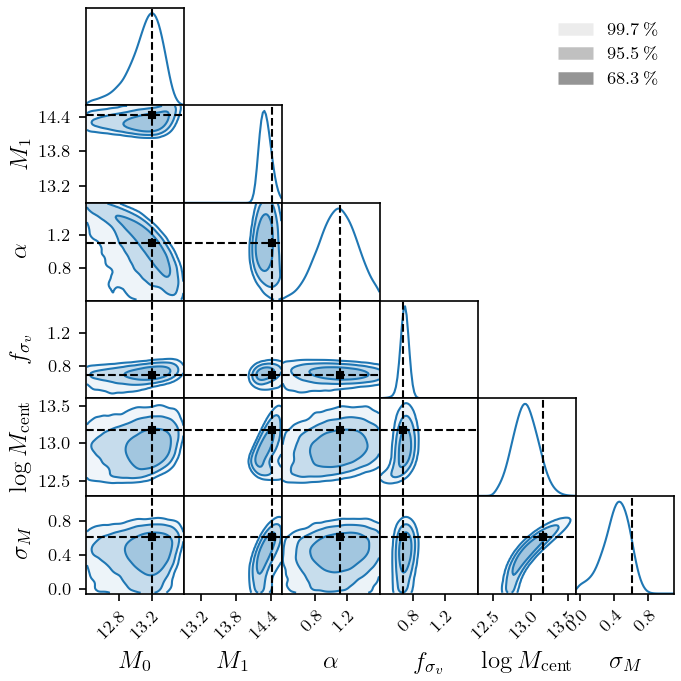

In [179]:
param_labels = {
    "Ac": r"$A_c$",
    "As": r"$A_s$",
    "M_0": r"$M_0$",
    "M_1": r"$M_1$",
    "Q": r"$Q$",
    "alpha": r"$\alpha$",
    # --- assembly bias parameters ---
    "ab_c_cen": r"$A_{B,\,c}^{\mathrm{cen}}$",
    "ab_c_sat": r"$A_{B,\,c}^{\mathrm{sat}}$",
    "ab_env_cen": r"$A_{B,\,\mathrm{env}}^{\mathrm{cen}}$",
    "ab_env_sat": r"$A_{B,\,\mathrm{env}}^{\mathrm{sat}}$",
    # --- other model parameters ---
    "f_sigv": r"$f_{\sigma_v}$",
    "gamma": r"$\gamma$",
    "log_Mcent": r"$\log M_{\mathrm{cent}}$",
    "pmax": r"$p_{\max}$",
    "sigma_M": r"$\sigma_M$",
    "exp_frac": r"$f_{\exp}$",
    "exp_scale": r"$s_{\exp}$",
    "nfw_rescale": r"$\lambda_{\mathrm{NFW}}$",
    "v_infall": r"$v_{\mathrm{infall}}$",
    "v_smear": r"$v_{\mathrm{smear}}$"
}


ii= np.random.choice(np.arange(len(train_Dataset.y_test_norm)), size=3, replace=False)
estimator.eval()
param_names = [param_labels[par[:-4]] for par in train_Dataset.name_arr]

for i in ii:
    with torch.no_grad():
        samples = estimator.flow(torch.from_numpy(train_Dataset.y_test_norm[i]).to(train_Dataset.device).float()).sample((2**16,))   
        samples_denorm = train_Dataset.normalizer.denormalize_x(samples.cpu())
    fig = corner(
        samples_denorm,
        smooth=2,
        figsize=(4.8, 4.8), 
        domain=(LOWER, UPPER),
        labels=list(param_names)
    )

    mark_point(fig, train_Dataset.X_test[i])